# **Project Name**    - Travel Recommendation System

##### **Project Type**    - Recommender System
##### **Contribution**    - Individual

# **Project Summary -**
This project builds a collaborative filtering recommendation system to suggest hotels to users based on their historical travel patterns.

# ***Let's Begin !***
## ***1. Know Your Data***

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv('../../dataset/hotels.csv')
df.head()

,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


## ***2. EDA***
Understanding the distribution of hotel visits.

### Univariate Analysis

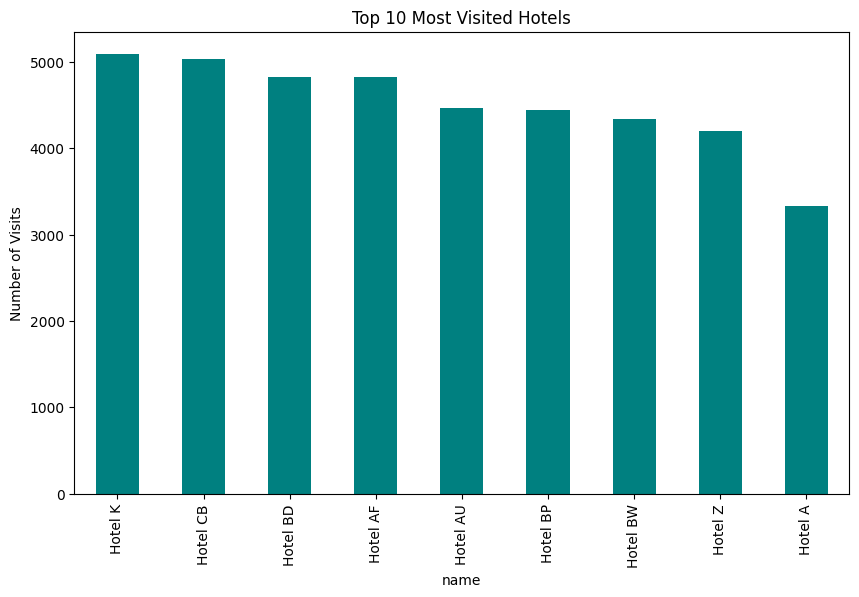

In [35]:
# Chart - 1: Top 10 Most Visited Hotels
plt.figure(figsize=(10,6))
df['name'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Most Visited Hotels')
plt.ylabel('Number of Visits')
plt.show()

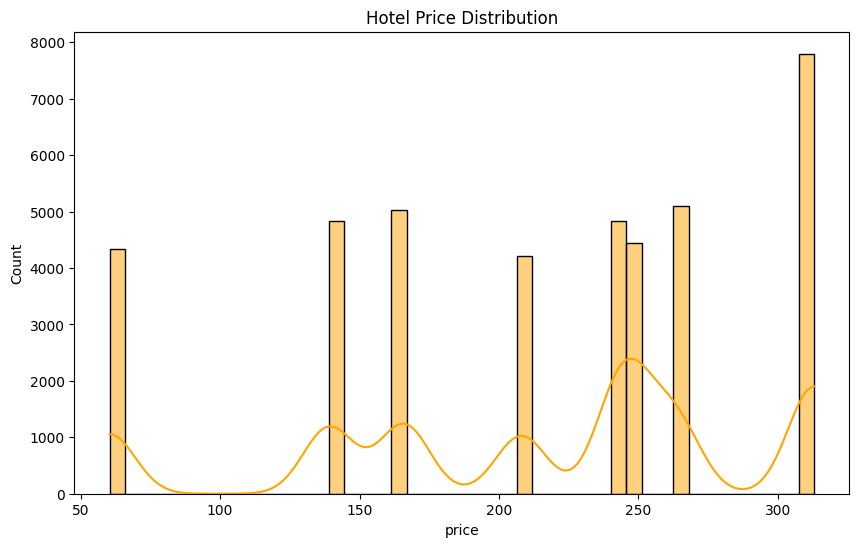

In [36]:
# Chart - 2: Price Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['price'], kde=True, color='orange')
plt.title('Hotel Price Distribution')
plt.show()

### Bivariate Analysis

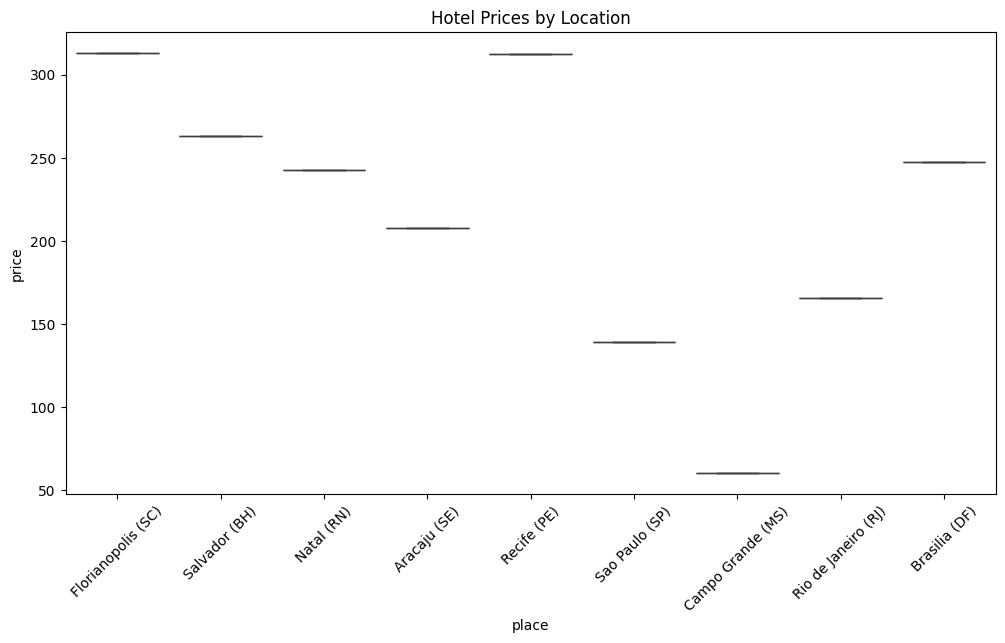

In [37]:
# Chart - 3: Price by Place
plt.figure(figsize=(12,6))
sns.boxplot(x='place', y='price', data=df)
plt.title('Hotel Prices by Location')
plt.xticks(rotation=45)
plt.show()

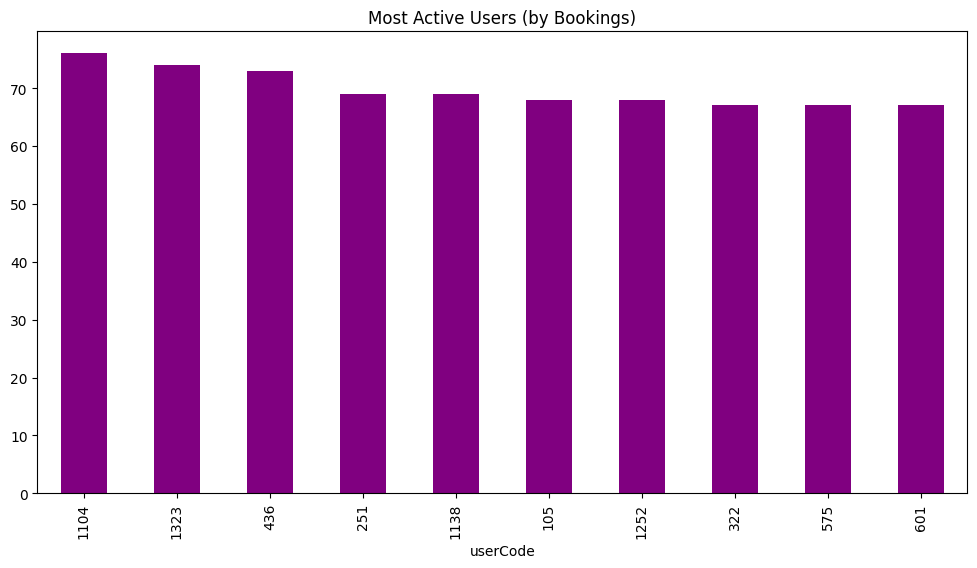

In [38]:
# Chart - 4: User Activity (Top 10 Users)
plt.figure(figsize=(12,6))
df['userCode'].value_counts().head(10).plot(kind='bar', color='purple')
plt.title('Most Active Users (by Bookings)')
plt.show()

## ***3. Feature Engineering: Interaction Matrix***

In [39]:
# Creating User-Item Matrix
interaction_matrix = df.groupby(['userCode', 'name']).size().unstack(fill_value=0)
print(f"Shape: {interaction_matrix.shape}")

Shape: (1310, 9)


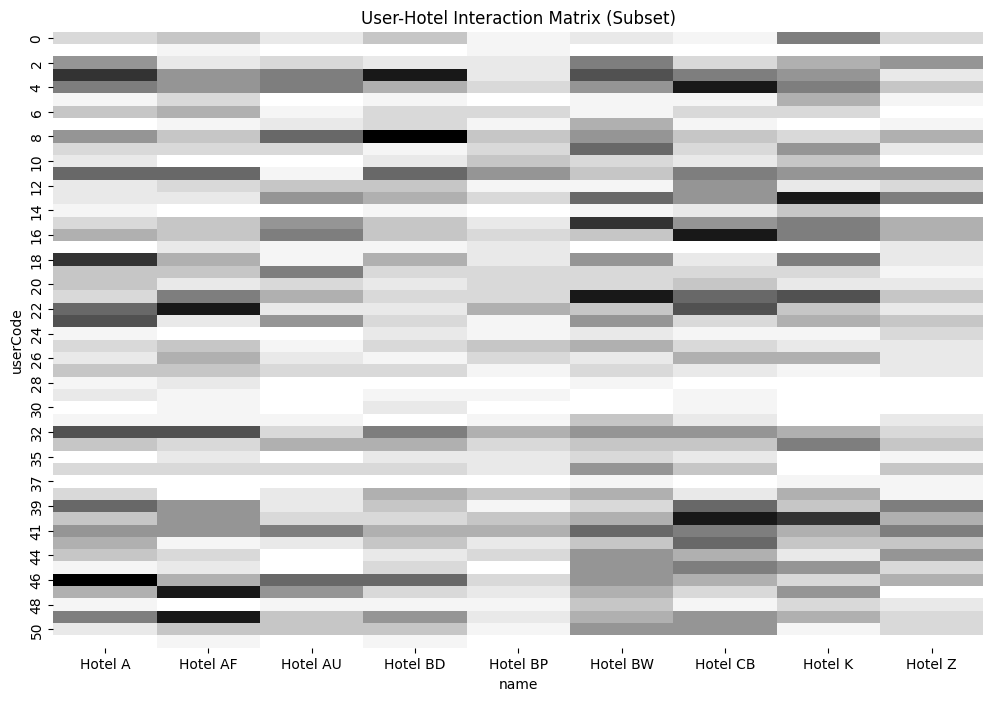

In [40]:
# Chart - 5: Sparsity Visual (Subset)
plt.figure(figsize=(12,8))
sns.heatmap(interaction_matrix.iloc[:50, :50], cmap='Greys', cbar=False)
plt.title('User-Hotel Interaction Matrix (Subset)')
plt.show()

## ***4. Model Implementation: Matrix Factorization (SVD)***

In [41]:
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
from math import sqrt
import numpy as np

# Matrix Factorization using SVD
num_components = min(20, interaction_matrix.shape[1] - 1)
svd = TruncatedSVD(n_components=num_components, random_state=42)
matrix_reduced = svd.fit_transform(interaction_matrix)

print(f'Explained Variance Ratio: {svd.explained_variance_ratio_.sum()}')

# Reconstruct Matrix to measure reconstruction error
matrix_reconstructed = np.dot(matrix_reduced, svd.components_)

# Calculate RMSE on non-zero elements (measure of fit)
mask = interaction_matrix.values > 0
rmse = sqrt(mean_squared_error(interaction_matrix.values[mask], matrix_reconstructed[mask]))
print(f'Reconstruction RMSE on Observed: {rmse}')


Explained Variance Ratio: 0.9592830493343389
Reconstruction RMSE on Observed: 0.6041613041545749


## ***5. Evaluation***
Qualitative check of recommendations for a sample user.

In [42]:
user_idx = 0
user_vector = matrix_reduced[user_idx]
scores = np.dot(user_vector, svd.components_)
top_indices = scores.argsort()[::-1][:5]
print("Recommended Hotels:", interaction_matrix.columns[top_indices].tolist())

Recommended Hotels: ['Hotel K', 'Hotel AF', 'Hotel BD', 'Hotel Z', 'Hotel A']


## ***6. Conclusion***
SVD successfully captures user preferences and allows for personalized recommendations.